In [64]:
import numpy as np
import os

def load_results_matrix(path: str = "../performance_based_selection/model_performance.npy"):
    if not os.path.exists(path):
        # Not an error: just return None so callers can fall back to defaults
        print(f"[info] results matrix not found at: {path}")
        return None
    try:
        arr = np.load(path, allow_pickle=True)
        # Coerce to ndarray for consistent handling (may be an object array)
        arr = np.array(arr, dtype=np.float32)
        print(f"[info] loaded results matrix from {path} with shape {arr.shape}")
        return arr
    except Exception as e:
        print(f"[warning] failed to load results matrix {path}: {e}")
        return None

# Expose loaded matrix as a module-level variable; callers can check for None.
results_matrix = load_results_matrix()

[info] loaded results matrix from ../performance_based_selection/model_performance.npy with shape (48, 48)


In [65]:
import torch
import torch.nn as nn
import json

class BilinearFusionScorer(nn.Module):
    """
    Learns Wi, Wr and returns softmax weights over K adapters given a batch of inputs.
    """
    def __init__(self, A_init: torch.Tensor, top_k: int, temperature: float = 1.0):
        super().__init__()
        self.register_buffer("A", A_init.clone())       # (K, d_a)
        self.top_k = top_k
        self.tau = temperature

    @torch.no_grad()
    def set_adapter_embeddings(self, A_new: torch.Tensor):
        self.A = A_new.clone().to(self.A.device)

    def forward(self, I: torch.Tensor, exclude_idx: int = None):
        """
        I: (B, d_in) input embeddings
        Returns:
          probs: (B, K) softmax weights per sample
          logits: (B, K)
        """
        return 0
    
device = "cuda" if torch.cuda.is_available() else "cpu"

cfg_path = "../performance_based_selection/models/base_model.config.json"
ckpt_path = "../performance_based_selection/models/base_model.pt"
    # Load scorer
with open(cfg_path) as f:
    cfg = json.load(f)

scorer = BilinearFusionScorer(
    A_init=torch.zeros(cfg["K"], 768, dtype=torch.bfloat16),  # placeholder, will be loaded
    top_k=3,
    temperature=cfg["temperature"],
).to(device)
if cfg["dtype"] == "bfloat16":
    scorer.bfloat16()

state = torch.load(ckpt_path, map_location="cpu")
scorer.load_state_dict(state)
scorer.to(device).eval()


/var/folders/wz/vf_j6__54d91gkttf0vr9pww0000gn/T/ipykernel_71044/2236295699.py:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt_path, map_location="

BilinearFusionScorer()

In [66]:
try:
    plot_matrix = np.array([[float(x) if x is not None else np.nan for x in row] for row in results_matrix])
except Exception:
    # Fallback: coerce with numpy (handles mixed types)
    plot_matrix = results_matrix.astype(np.float64)

with np.errstate(invalid='ignore'):
    row_min = np.nanmin(plot_matrix, axis=1, keepdims=True)
    row_max = np.nanmax(plot_matrix, axis=1, keepdims=True)
denom = row_max - row_min
# Avoid division by zero: where denom == 0, set denom to 1 temporarily
denom_safe = np.where(np.isfinite(denom) & (denom != 0), denom, 1.0)
norm_matrix = (plot_matrix - row_min) / denom_safe
# For rows where denom was zero (constant rows), set normalized values to 0
const_rows = (denom == 0).squeeze(axis=1)
if np.any(const_rows):
    norm_matrix[const_rows, :] = 0.0

# Keep NaNs where original data had NaNs
norm_matrix[np.isnan(plot_matrix)] = np.nan

0 0
[[1.         0.19501714]
 [0.19501714 1.        ]]


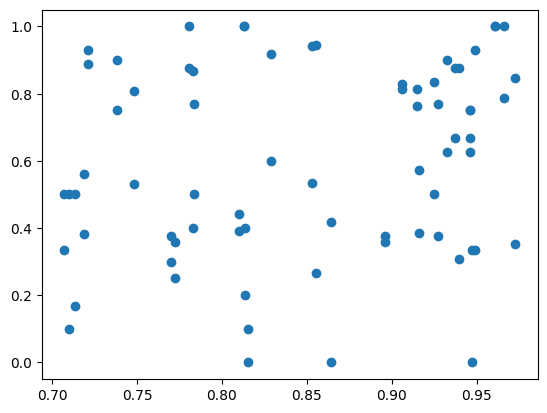

In [ ]:
import matplotlib.pyplot as plt

all_model_sims = np.array([])
all_model_performances = np.array([])

for model_id in range(47):
    model_performance = norm_matrix[:, model_id]
    # Cast bfloat16 buffer to float32 before converting to numpy to avoid unsupported dtype error
    A_float = scorer.A.to(torch.float32).cpu().numpy()
    model_sim = A_float @ A_float[model_id, :]

    # Optional: normalize similarity (cosine) if desired
    from numpy.linalg import norm
    model_sim_cosine = model_sim / (np.linalg.norm(A_float, axis=1) * np.linalg.norm(A_float[model_id]))
    all_model_sims = np.append(all_model_sims, model_sim_cosine[(model_sim_cosine>0.8)*(model_sim_cosine<0.98)])
    all_model_performances = np.append(all_model_performances, model_performance[(model_sim_cosine>0.8)*(model_sim_cosine<0.98)])
    #all_model_sims = np.append(all_model_sims, model_sim_cosine[model_sim_cosine.argsort()[-3:]])
    # all_model_performances = np.append(all_model_performances, model_performance[model_sim_cosine.argsort()[-10:]])
    # all_model_sims = np.append(all_model_sims, model_sim_cosine[model_sim_cosine.argsort()[-3:]])
    # all_model_performances = np.append(all_model_performances, model_performance[model_sim_cosine.argsort()[-3:]])
    

plt.plot(all_model_sims, all_model_performances, 'o')
print(np.isnan(all_model_sims).sum(), np.isnan(all_model_performances).sum())
print(np.corrcoef(all_model_sims, all_model_performances))

0 0
[[ 1.         -0.30546016]
 [-0.30546016  1.        ]]
0.8816059156393663
0.6879757569579045
0.6636643308569055
0.5951318519012019
0.54425159250439
0.5393286498121793
0.5693514503268323
0.570570497732438
0.4766855526469557
0.5325196282312108


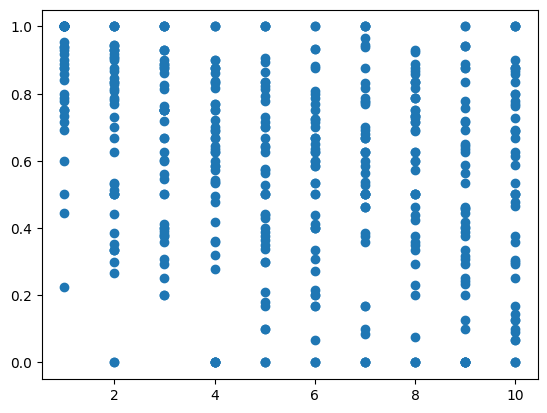

In [68]:
import matplotlib.pyplot as plt

all_model_sims = np.array([])
all_model_performances = np.array([])

for model_id in range(47):
    model_performance = norm_matrix[:, model_id]
    # Cast bfloat16 buffer to float32 before converting to numpy to avoid unsupported dtype error
    A_float = scorer.A.to(torch.float32).cpu().numpy()
    model_sim = A_float @ A_float[model_id, :]

    # Optional: normalize similarity (cosine) if desired
    from numpy.linalg import norm
    model_sim_cosine = model_sim / (np.linalg.norm(A_float, axis=1) * np.linalg.norm(A_float[model_id]))
    all_model_sims = np.append(all_model_sims, np.arange(10,0,-1))
    all_model_performances = np.append(all_model_performances, model_performance[model_sim_cosine.argsort()[-10:]])
    

plt.plot(all_model_sims, all_model_performances, 'o')
print(np.isnan(all_model_sims).sum(), np.isnan(all_model_performances).sum())
print(np.corrcoef(all_model_sims, all_model_performances))
for i in range(1,11):
    print(np.mean(all_model_performances[all_model_sims == i]))

0.8816059156393663
0.9286182810056867
0.9467989163045717
0.9492489482303236
0.9607501532426526
0.9660679451967427
0.9706062169463816
0.9708721741266735
0.9763487827564282
0.9790083572245134
0.9790083572245134
0.9867063492063491
0.9867063492063491
0.9867063492063491
0.9867063492063491
0.9880361364403917
0.9880361364403917
0.9880361364403917
0.9880361364403917
0.9906957109084769
0.9906957109084769
0.9924687605538671
0.9924687605538671
0.9924687605538671
0.9924687605538671
0.9924687605538671
0.9924687605538671
0.9924687605538671
0.9924687605538671
0.9924687605538671
0.9924687605538671
0.9924687605538671
0.994596420128335
0.994596420128335
0.994596420128335
0.994596420128335
0.994596420128335
0.994596420128335
0.9976359338061465
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0


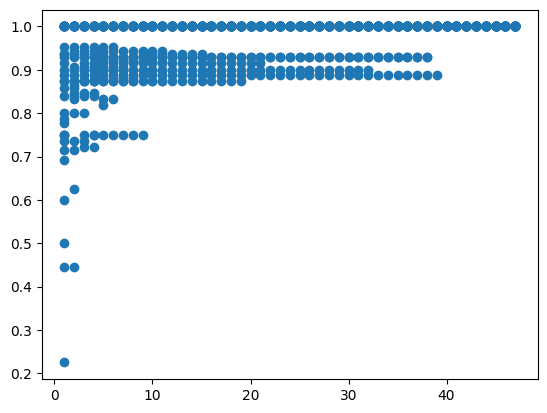

In [69]:
import matplotlib.pyplot as plt

all_model_sims = np.array([])
all_model_performances = np.array([])

for task_id in range(47):
    model_performance = norm_matrix[task_id, :]
    # Cast bfloat16 buffer to float32 before converting to numpy to avoid unsupported dtype error
    A_float = scorer.A.to(torch.float32).cpu().numpy()
    model_sim = A_float @ A_float[task_id, :]

    # Optional: normalize similarity (cosine) if desired
    from numpy.linalg import norm
    model_sim_cosine = model_sim / (np.linalg.norm(A_float, axis=1) * np.linalg.norm(A_float[model_id]))
    all_model_sims = np.append(all_model_sims, np.arange(1, 48))
    for i in range(1,48):
        all_model_performances = np.append(all_model_performances, np.max(model_performance[model_sim_cosine.argsort()[-i:]]))
    

plt.plot(all_model_sims, all_model_performances, 'o')
for i in range(1,48):
    print(np.mean(all_model_performances[all_model_sims == i]))

In [87]:
import os
import json
from collections import defaultdict
from nltk.translate.bleu_score import sentence_bleu
from rouge import Rouge
import numpy as np
import pandas as pd

# Function to calculate BLEU score
def calculate_bleu(references, candidates):
    scores = [sentence_bleu([ref.split()], cand.split()) for ref, cand in zip(references, candidates)]
    return np.round(np.mean(scores) * 100, 1) if scores else 0

# Function to calculate ROUGE score
def calculate_rouge(references, candidates):
    rouge = Rouge()
    scores = rouge.get_scores(candidates, references, avg=True)
    rouge_1 = np.round(scores['rouge-1']['f'] * 100, 1)
    rouge_2 = np.round(scores['rouge-2']['f'] * 100, 1)
    rouge_l = np.round(scores['rouge-l']['f'] * 100, 1)
    return rouge_1, rouge_2, rouge_l

# Function to calculate Exact Match score
def calculate_em(references, candidates):
    references = [ref.split("\n\n")[0] for ref in references]
    em_scores = [1 if cal_correct(ref, cand) else 0 for ref, cand in zip(references, candidates)]
    return np.round(np.mean(em_scores) * 100, 1) if em_scores else 0

def cal_correct(generated_answer, expected_answer):
    is_correct = generated_answer.strip().lower().replace(".", "") == expected_answer.strip().lower().replace(".", "")
    return is_correct

# Function to process a file
def process_file(file_path):
    with open(file_path, 'r') as file:
        data = json.load(file)

    organized_data = defaultdict(lambda: defaultdict(list))
    for entry in data:
        domain = entry['model_name']
        task = entry['model_name']
        organized_data[domain][task].append(entry)
    
    return organized_data

# Function to process all files in a folder and aggregate scores by domain and metric
def process_folder(folder_path):
    domain_specific_metrics = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
    for file_name in os.listdir(folder_path):
        if not (file_name.startswith('model_loss') or file_name.startswith('degraded_model')) and file_name.endswith('.json'):
            file_path = os.path.join(folder_path, file_name)
            domains_data = process_file(file_path)

            for domain, tasks_data in domains_data.items():
                for task, entries in tasks_data.items():
                    metric = entries[0]['metric']
                    references = [entry['targets'] for entry in entries]
                    candidates = [entry['predicted_answer'] for entry in entries]

                    if metric == 'bleu':
                        score = calculate_bleu(references, candidates)
                        domain_specific_metrics[domain][metric][file_name].append(score)
                    elif metric == 'rouge':
                        rouge_1, rouge_2, rouge_l = calculate_rouge(references, candidates)
                        domain_specific_metrics[domain]['rouge-avg'][file_name].append((rouge_1+rouge_2+rouge_l)/3)
                        # domain_specific_metrics[domain]['rouge-1'][file_name].append(rouge_1)
                        # domain_specific_metrics[domain]['rouge-2'][file_name].append(rouge_2)
                        # domain_specific_metrics[domain]['rouge-l'][file_name].append(rouge_l)
                    elif metric == 'em':
                        score = calculate_em(references, candidates)
                        domain_specific_metrics[domain][metric][file_name].append(score)
    
    return domain_specific_metrics

# Function to convert data to LaTeX format with domain and metric averages
def convert_to_latex_modified(data, folder_path):
    data_list = []
    for domain, metrics in data.items():
        for metric, files in metrics.items():
            row = {'Domain-Metric': f"{domain}-{metric}"}
            for file_name in os.listdir(folder_path):
                if not (file_name.startswith('model_loss') or file_name.startswith('degraded_model')) and file_name.endswith('.json'):
                    numeric_scores = [score for score in files[file_name] if isinstance(score, (int, float))]
                    average_score = np.mean(numeric_scores) if numeric_scores else 0
                    row[file_name] = "{:.1f}".format(average_score)  # Format to one decimal place
            data_list.append(row)

    df = pd.DataFrame(data_list)
    columns_ordered = ['Domain-Metric'] + [file_name for file_name in os.listdir(folder_path) if not (file_name.startswith('model_loss') or file_name.startswith('degraded_model')) and file_name.endswith('.json')]
    df = df[columns_ordered]
    results = []
    tasks = []
    for d in data_list:
        results.append([])
        tasks.append(d.get('Domain-Metric', ''))
        for model_id in range(48):
            results[-1].append(d.get(f'model_{model_id}.json', None))
    
    results = np.array(results)

    return results, tasks


# Example usage
folder_path = '../performance_large/outputs'  # Replace with your actual folder path
processed_data = process_folder(folder_path)
results, tasks = convert_to_latex_modified(processed_data, folder_path)
#print(latex_table)


In [71]:
try:
    plot_matrix = np.array([[float(x) if x is not None else np.nan for x in row] for row in results])
except Exception:
    # Fallback: coerce with numpy (handles mixed types)
    plot_matrix = results.astype(np.float64)

with np.errstate(invalid='ignore'):
    row_min = np.nanmin(plot_matrix, axis=1, keepdims=True)
    row_max = np.nanmax(plot_matrix, axis=1, keepdims=True)
denom = row_max - row_min
# Avoid division by zero: where denom == 0, set denom to 1 temporarily
denom_safe = np.where(np.isfinite(denom) & (denom != 0), denom, 1.0)
results_norm = (plot_matrix - row_min) / denom_safe
# For rows where denom was zero (constant rows), set normalized values to 0
const_rows = (denom == 0).squeeze(axis=1)
if np.any(const_rows):
    results_norm[const_rows, :] = 0.0

# Keep NaNs where original data had NaNs
results_norm[np.isnan(plot_matrix)] = np.nan

In [111]:
per_task_performance = np.array([])
for task_id in range(48):
    model_performance = norm_matrix[task_id, :]
    # Cast bfloat16 buffer to float32 before converting to numpy to avoid unsupported dtype error
    A_float = scorer.A.to(torch.float32).cpu().numpy()
    model_sim = A_float @ A_float[task_id, :]

    # Optional: normalize similarity (cosine) if desired
    from numpy.linalg import norm
    model_sim_cosine = model_sim / (np.linalg.norm(A_float, axis=1) * np.linalg.norm(A_float[model_id]))
    selected_model = np.argmax(model_performance*(model_sim_cosine>0.7))
    per_task_performance = np.append(per_task_performance, results_norm[task_id,selected_model])

print(per_task_performance.mean())
par_tasks = ['paws_wiki-em', 'glue_qqp-em', 'glue_mrpc-em', 'stsb-em']
res = 0
for par_task in par_tasks:
    res += per_task_performance[tasks.index(par_task)]
print(res/len(par_tasks))

0.9543469866347928
0.9951923076923077
